# Wikipedia Editing Event Study: US Federal Elections 2016-2024

**Version: 12/07/2025**
This notebook implements an event study with window design that specifically 
1. uses non-overlapping 2-year cycles to prevent contamination
2. excludes immediate post-election editing spikes
3. focuses on editing behavior changes before elections

## Data Steps
- Run `01_build_candidate_roster.py --major-only --sample 0.05` to create FEC-candidate master file-based roster. (5% sample of 30101 REP/DEM candidates). Done through matching Wikipedia pages with a confidence threshold of 0.6. (does create errors)
- Run `02_collect_revisions.py --config candidates` to collect revisions
- Run `03_process_data.py --config candidates` to process data

**Note**: As of right now, the analysis uses a sample of Wiki pages of politicians who ran for a given cycle AND have a Wiki page. FEC Candidate master file does not contain information on whether that candidate actually appeated on the November ballot. Ballot access is controlled by the state. 

**[TODO]**: 
1) Collect pages of candidates who appeared on the November ballot AND have Wikipedia pages, probably through directly parsing Wikipedia pages on elections. (https://en.wikipedia.org/wiki/2022_United_States_House_of_Representatives_elections#Arizona)
2) DiD with off-ballot candidates. 
3) Separately consider general informational pages, which may demonstrate different editing patterns (perhaps less contested, less astroturfing, etc. )

In [131]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import json
from datetime import datetime, date, timedelta
from pathlib import Path
import warnings
import sys

# Add scripts to path for election_cycles module
sys.path.append('../scripts')

warnings.filterwarnings('ignore')
sns.set_style('whitegrid')
%matplotlib inline

plt.rcParams['figure.figsize'] = (14, 6)
plt.rcParams['font.size'] = 11

print("Environment configured")


Environment configured


In [132]:
# Import election cycle utilities
from election_cycles import (
    get_election_day, get_cycle_windows, get_study_cycles,
    date_to_event_time, get_on_ballot_indicator,
    is_presidential_year, ELECTION_METADATA
)

# Display election days and cycles
print("Election Days:")
for year in [2016, 2018, 2020, 2022, 2024]:
    ed = get_election_day(year)
    print(f"  {year}: {ed.strftime('%A, %B %d, %Y')}")

print("\nStudy Cycles:")
cycles = get_study_cycles(2016, 2024)
for c in cycles:
    print(f"  {c['election_year']}: {c['cycle_start']} to {c['cycle_end']} ({c['type']})")


Election Days:
  2016: Tuesday, November 08, 2016
  2018: Tuesday, November 06, 2018
  2020: Tuesday, November 03, 2020
  2022: Tuesday, November 08, 2022
  2024: Tuesday, November 05, 2024

Study Cycles:
  2016: 2014-11-05 to 2016-11-08 (presidential)
  2018: 2016-11-09 to 2018-11-06 (midterm)
  2020: 2018-11-07 to 2020-11-03 (presidential)
  2022: 2020-11-04 to 2022-11-08 (midterm)
  2024: 2022-11-09 to 2024-11-05 (presidential)


## 1. Load Data and Overview Statistics

In [144]:
# Try to load candidate roster data first, fall back to US data
data_dir_candidates = Path('../data/processed_candidates')
data_dir_us = Path('../data/processed_us')

# Check what data is available
if data_dir_candidates.exists() and (data_dir_candidates / 'daily_edits.csv').exists():
    data_dir = data_dir_candidates
    print("Using candidate roster data (FEC-based)")
elif data_dir_us.exists():
    data_dir = data_dir_us
    print("Using US data (Wikipedia category-based)")
else:
    raise FileNotFoundError("No processed data found. Run the data collection pipeline first.")

# Load daily edits
df_daily = pd.read_csv(data_dir / 'daily_edits.csv', parse_dates=['date'])
df_pages = pd.read_csv(data_dir / 'page_statistics.csv')

# Load on_ballot information from the candidate roster JSON
roster_path = Path('../data/raw/candidate_roster_final.json')
if roster_path.exists():
    with open(roster_path, 'r') as f:
        roster_data = json.load(f)
    
    # Create on_ballot lookup from roster data
    on_ballot_lookup = {}
    for page in roster_data['pages']:
        title = page['title']
        on_ballot_lookup[title] = page.get('on_ballot', {})
    
    print(f"Loaded yearly candidate info for {len(on_ballot_lookup)} pages from roster")
    
    # Add on_ballot columns to df_pages
    for year in [2016, 2018, 2020, 2022, 2024]:
        df_pages[f'on_ballot_{year}'] = df_pages['page_title'].apply(
            lambda x: on_ballot_lookup.get(x, {}).get(str(year), False)
        )
    
    print("\nSampled candidate page counts by year:")
    for year in [2016, 2018, 2020, 2022, 2024]:
        count = df_pages[f'on_ballot_{year}'].sum()
        print(f"  {year}: {count} pages")
else:
    print("Warning: candidate_roster_final.json not found, cannot load on_ballot info")
    on_ballot_lookup = {}

# Basic statistics
print("\nDataset Overview - Election Candidates")
print("=" * 60)
print(f"Pages: {len(df_pages)}")
print(f"Date range: {df_daily['date'].min()} to {df_daily['date'].max()}")
print(f"Total days: {len(df_daily['date'].unique())}")
print(f"Total edits: {df_daily['num_edits'].sum():,}")
print(f"\nTop 10 Most Edited Pages:")
print(df_pages.nlargest(10, 'total_edits')[['page_title', 'total_edits', 'unique_editors']])

Using candidate roster data (FEC-based)
Loaded yearly candidate info for 400 pages from roster

Sampled candidate page counts by year:
  2016: 84 pages
  2018: 112 pages
  2020: 75 pages
  2022: 97 pages
  2024: 94 pages

Dataset Overview - Election Candidates
Pages: 400
Date range: 2014-11-01 00:00:00 to 2024-12-31 00:00:00
Total days: 3714
Total edits: 138,717

Top 10 Most Edited Pages:
           page_title  total_edits  unique_editors
113  Elizabeth Warren         3605             971
252       Marco Rubio         3255            1060
291      Nancy Pelosi         2651             879
59     Chris Christie         2632            1094
194        John Lewis         2440            1082
166     Jeff Sessions         2427             869
382        Tom Cotton         2424             926
196       John McCain         2334             732
161          Jeb Bush         2332             844
228    Kyrsten Sinema         2301             942


## 2. Time Series: Daily Editing Activity

**Moving Averages**: All MAs use *backward-looking windows*. The 7-day moving average at day *t* represents the average of days (*t*-6, *t*-5, ..., *t*-1, *t*). This ensures pre-election averages are not contaminated by post-election editing activity.

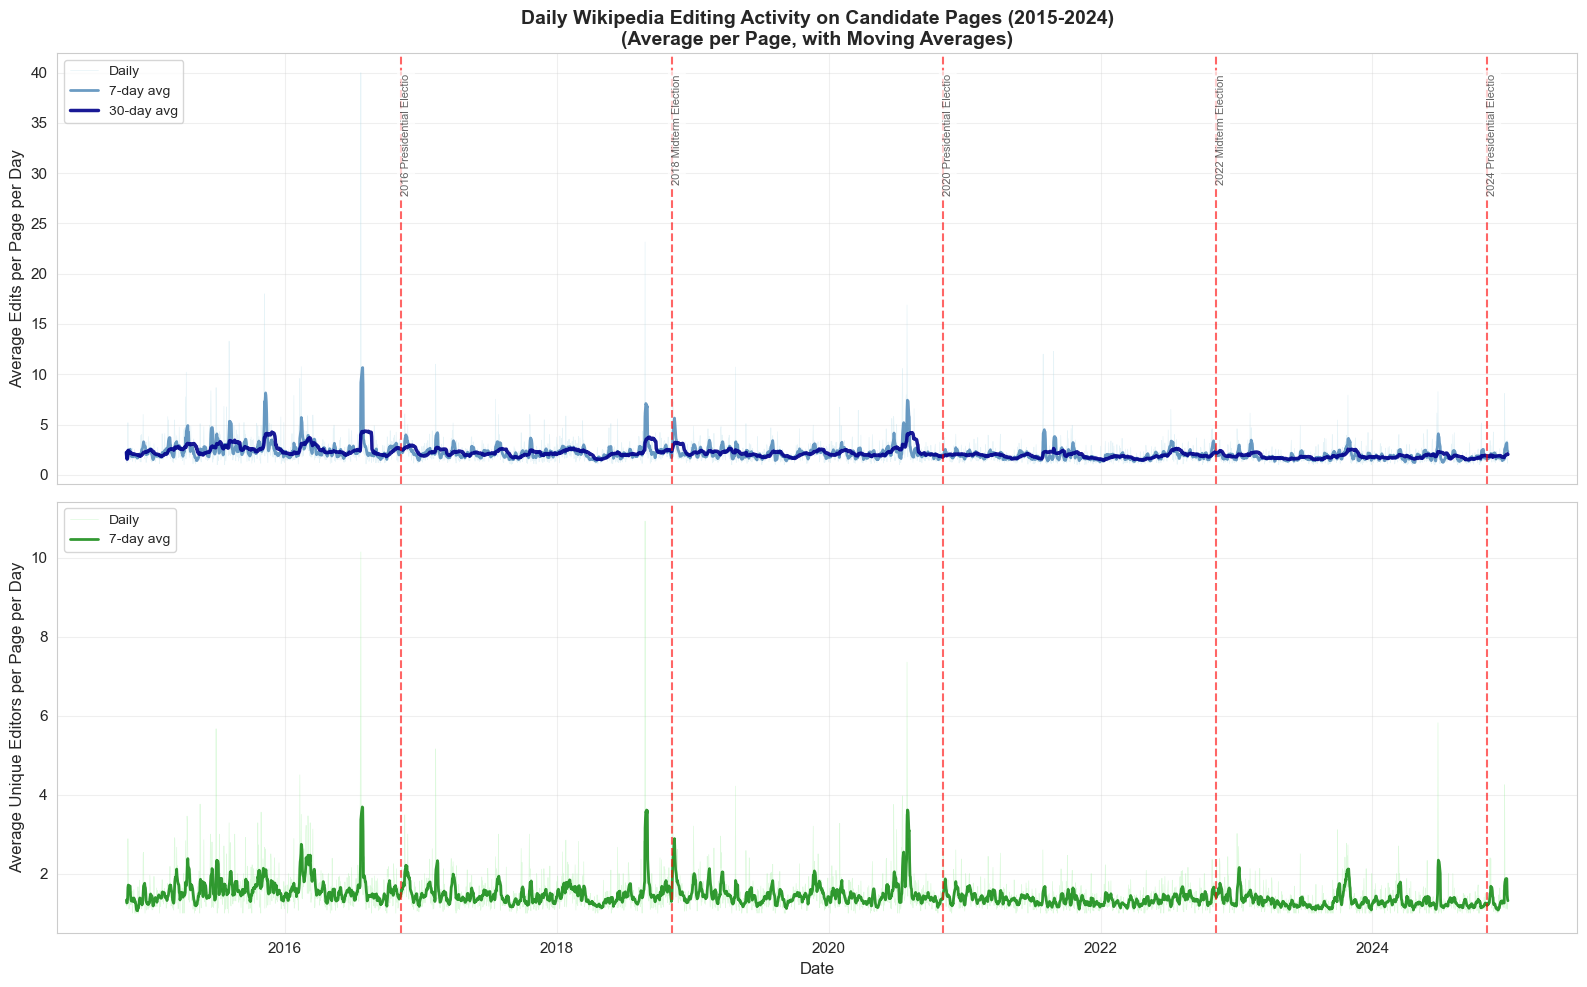


Note: Both metrics are averaged per page to control for varying dataset size across time.


In [134]:
# Create events dataframe from election metadata
events_list = []
for year in [2016, 2018, 2020, 2022, 2024]:
    election_day = get_election_day(year)
    election_type = ELECTION_METADATA.get(year, {}).get('type', 'unknown')
    events_list.append({
        'date': pd.Timestamp(election_day),
        'name': f'{year} {election_type.capitalize()} Election',
        'type': election_type
    })
events = pd.DataFrame(events_list)

# Aggregate daily activity - AVERAGE PER PAGE (not sum)
daily_aggregate = df_daily.groupby('date').agg({
    'num_edits': 'mean',  # Average edits per page per day
    'unique_editors': 'mean',  # Average editors per page per day
    'page_title': 'nunique'  # Number of pages with data on this day
}).reset_index()
daily_aggregate.columns = ['date', 'mean_edits_per_page', 'mean_editors_per_page', 'num_pages']

# Calculate moving averages (backward-looking)
daily_aggregate['ma7_edits'] = daily_aggregate['mean_edits_per_page'].rolling(window=7, min_periods=1).mean()
daily_aggregate['ma30_edits'] = daily_aggregate['mean_edits_per_page'].rolling(window=30, min_periods=1).mean()
daily_aggregate['ma7_editors'] = daily_aggregate['mean_editors_per_page'].rolling(window=7, min_periods=1).mean()

# Create time series plot
fig, axes = plt.subplots(2, 1, figsize=(16, 10), sharex=True)

# Plot 1: Edit volume (AVERAGE PER PAGE)
axes[0].plot(daily_aggregate['date'], daily_aggregate['mean_edits_per_page'], 
            linewidth=0.5, alpha=0.3, color='lightblue', label='Daily')
axes[0].plot(daily_aggregate['date'], daily_aggregate['ma7_edits'], 
            linewidth=2, alpha=0.8, color='steelblue', label='7-day avg')
axes[0].plot(daily_aggregate['date'], daily_aggregate['ma30_edits'], 
            linewidth=2.5, alpha=0.9, color='darkblue', label='30-day avg')

axes[0].set_ylabel('Average Edits per Page per Day', fontsize=12)
axes[0].set_title('Daily Wikipedia Editing Activity on Candidate Pages (2015-2024)\n(Average per Page, with Moving Averages)', 
                 fontsize=14, fontweight='bold')
axes[0].grid(True, alpha=0.3)
axes[0].legend(loc='upper left', fontsize=10)

# Mark political events
for _, event in events.iterrows():
    axes[0].axvline(event['date'], color='red', linestyle='--', alpha=0.6, linewidth=1.5)
    y_pos = axes[0].get_ylim()[1] * 0.95
    axes[0].text(event['date'], y_pos, 
                event['name'][:25], rotation=90, 
                verticalalignment='top', fontsize=8, alpha=0.7,
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7))

# Plot 2: Unique editors (AVERAGE PER PAGE)
axes[1].plot(daily_aggregate['date'], daily_aggregate['mean_editors_per_page'], 
            linewidth=0.5, alpha=0.3, color='lightgreen', label='Daily')
axes[1].plot(daily_aggregate['date'], daily_aggregate['ma7_editors'], 
            linewidth=2, alpha=0.8, color='green', label='7-day avg')
axes[1].set_ylabel('Average Unique Editors per Page per Day', fontsize=12)
axes[1].set_xlabel('Date', fontsize=12)
axes[1].grid(True, alpha=0.3)
axes[1].legend(loc='upper left', fontsize=10)

for _, event in events.iterrows():
    axes[1].axvline(event['date'], color='red', linestyle='--', alpha=0.6, linewidth=1.5)

plt.tight_layout()
plt.show()

print(f"\nNote: Both metrics are averaged per page to control for varying dataset size across time.")

## 3. Page Categorization

Categorize candidate pages into meaningful groups for analysis.

In [135]:
# =============================================================================
# COMPREHENSIVE DATA STATISTICS
# =============================================================================

print("=" * 80)
print("COMPREHENSIVE CANDIDATE ROSTER STATISTICS")
print("=" * 80)

if roster_path.exists():
    # Load metadata from roster
    metadata = roster_data['metadata']
    stats = metadata.get('statistics', {})
    
    print("\n1. FEC CANDIDATE INPUT DATA")
    print("-" * 80)
    print(f"   Total FEC candidate records processed: Available in roster metadata")
    print(f"   Election cycles covered: {', '.join(map(str, metadata.get('cycles', [])))}")
    
    print("\n2. WIKIPEDIA PAGE MATCHING")
    print("-" * 80)
    print(f"   Total Wikipedia pages matched: {metadata.get('total_pages', 0)}")
    print(f"   Wikipedia pages in analysis: {len(df_pages)}")
    
    # Breakdown by office
    print("\n3. BREAKDOWN BY OFFICE")
    print("-" * 80)
    office_breakdown = stats.get('by_office', {})
    for office, count in sorted(office_breakdown.items(), key=lambda x: x[1], reverse=True):
        print(f"   {office:12s}: {count:3d} pages")
    
    # Breakdown by party
    print("\n4. BREAKDOWN BY PARTY")
    print("-" * 80)
    party_breakdown = stats.get('by_party', {})
    for party, count in sorted(party_breakdown.items(), key=lambda x: x[1], reverse=True):
        print(f"   {party:12s}: {count:3d} pages")
    
    # Breakdown by cycle (on-ballot)
    print("\n5. ON-BALLOT PAGES BY ELECTION CYCLE")
    print("-" * 80)
    on_ballot_counts = stats.get('on_ballot_counts', {})
    for year in sorted(on_ballot_counts.keys()):
        count = on_ballot_counts[year]
        election_type = ELECTION_METADATA.get(int(year), {}).get('type', 'unknown')
        print(f"   {year} ({election_type:12s}): {count:3d} pages on ballot")
    print("\n- Candidates may appear in multiple cycles if they ran in multiple elections")
    
    # Detailed cycle breakdown with office and party
    print("\n6. DETAILED BREAKDOWN BY CYCLE, OFFICE, AND PARTY")
    print("-" * 80)
    
    for year in [2016, 2018, 2020, 2022, 2024]:
        election_type = ELECTION_METADATA.get(year, {}).get('type', 'unknown')
        print(f"\n   {year} {election_type.capitalize()} Election:")
        
        # Count by office and party for this cycle
        cycle_office = {}
        cycle_party = {}
        
        for page in roster_data['pages']:
            # Check if on ballot this year
            if page.get('on_ballot', {}).get(str(year), False):
                # Get cycle details
                cycle_details = page.get('cycles_on_ballot_details', {}).get(str(year), {})
                
                office = cycle_details.get('office', 'Unknown')
                party = cycle_details.get('party', 'Unknown')
                
                cycle_office[office] = cycle_office.get(office, 0) + 1
                cycle_party[party] = cycle_party.get(party, 0) + 1
        
        # Display office breakdown
        print(f"      By Office:")
        for office, count in sorted(cycle_office.items(), key=lambda x: x[1], reverse=True):
            print(f"         {office:12s}: {count:3d}")
        
        # Display party breakdown  
        print(f"      By Party:")
        for party, count in sorted(cycle_party.items(), key=lambda x: x[1], reverse=True):
            print(f"         {party:12s}: {count:3d}")
    
    print("\n" + "=" * 80)
    print("NOTES:")
    print("- Office/party may differ across cycles for the same candidate")
    print("- All statistics are based on successfully matched Wikipedia pages")
    
else:
    print("\nWarning: Roster data not available - cannot display comprehensive statistics")


COMPREHENSIVE CANDIDATE ROSTER STATISTICS

1. FEC CANDIDATE INPUT DATA
--------------------------------------------------------------------------------
   Total FEC candidate records processed: Available in roster metadata
   Election cycles covered: 2016, 2018, 2020, 2022, 2024

2. WIKIPEDIA PAGE MATCHING
--------------------------------------------------------------------------------
   Total Wikipedia pages matched: 400
   Wikipedia pages in analysis: 400

3. BREAKDOWN BY OFFICE
--------------------------------------------------------------------------------
   House       : 309 pages
   Senate      :  68 pages
   President   :  23 pages

4. BREAKDOWN BY PARTY
--------------------------------------------------------------------------------
   Republican  : 207 pages
   Democratic  : 193 pages

5. ON-BALLOT PAGES BY ELECTION CYCLE
--------------------------------------------------------------------------------
   2016 (presidential):  84 pages on ballot
   2018 (midterm     ): 112 pa

## 4. Pre-Election Dynamics Analysis
Analyze editing behavior changes using 2-year non-overlapping cycles.

**Notation:**
- **W (Washout)**: 30 days after previous election (to exclude post-election info updates)
- **L (Pre-election window)**: 60 days before current election
- **Baseline**: (E_{y-2} + W, E_y - L]
- **Pre-election**: (E_y - L, E_y) - event window of interest

For each cycle, I only analyze pages where the candidate was running during that cycle.

In [136]:
# Define cycle parameters
WASHOUT_DAYS = 30  # W: days after previous election to exclude
PRE_ELECTION_DAYS = 100  # L: pre-election event window

print("Parameters:")
print(f"  W (Washout): {WASHOUT_DAYS} days after previous election")
print(f"  L (Pre-election window): {PRE_ELECTION_DAYS} days before election")

print("\n" + "="*80)
print("ANALYSIS PER CYCLE")
print("="*80)

# Analyze each cycle
cycle_results = []

for year in [2016, 2018, 2020, 2022, 2024]:
    # Get cycle windows
    windows = get_cycle_windows(year, PRE_ELECTION_DAYS, WASHOUT_DAYS)
    election_day = get_election_day(year)
    election_type = ELECTION_METADATA.get(year, {}).get('type', 'unknown')
    
    # Get pages on ballot for this year
    if f'on_ballot_{year}' in df_pages.columns:
        pages_on_ballot = df_pages[df_pages[f'on_ballot_{year}'] == True]['page_title'].tolist()
    else:
        # Fallback: use all pages
        pages_on_ballot = df_pages['page_title'].tolist()
    
    print(f"\n{year} {election_type.capitalize()} Election ({election_day})")
    print(f"  Pages on ballot: {len(pages_on_ballot)}")
    print(f"  Washout: {windows['washout'][0]} to {windows['washout'][1]}")
    print(f"  Baseline: {windows['baseline'][0]} to {windows['baseline'][1]}")
    print(f"  Pre-election: {windows['pre_election'][0]} to {windows['pre_election'][1]}")
    
    # Filter data for this cycle and on-ballot pages only
    df_cycle = df_daily[df_daily['page_title'].isin(pages_on_ballot)].copy()
    
    # Get baseline period data
    baseline_mask = (df_cycle['date'].dt.date >= windows['baseline'][0]) & \
                    (df_cycle['date'].dt.date <= windows['baseline'][1])
    baseline_data = df_cycle[baseline_mask]
    
    # Get pre-election period data
    pre_election_mask = (df_cycle['date'].dt.date >= windows['pre_election'][0]) & \
                        (df_cycle['date'].dt.date <= windows['pre_election'][1])
    pre_election_data = df_cycle[pre_election_mask]
    
    # Compute average edits per page per day for each window
    if len(baseline_data) > 0:
        baseline_avg = baseline_data.groupby('date')['num_edits'].mean().mean()
    else:
        baseline_avg = 0
    
    if len(pre_election_data) > 0:
        pre_election_avg = pre_election_data.groupby('date')['num_edits'].mean().mean()
    else:
        pre_election_avg = 0
    
    # Calculate change
    if baseline_avg > 0:
        pct_change = ((pre_election_avg - baseline_avg) / baseline_avg) * 100
    else:
        pct_change = 0
    
    print(f"  Baseline avg: {baseline_avg:.3f} edits/page/day")
    print(f"  Pre-election avg: {pre_election_avg:.3f} edits/page/day")
    print(f"  Change: {pct_change:+.1f}%")
    
    cycle_results.append({
        'year': year,
        'type': election_type,
        'pages_on_ballot': len(pages_on_ballot),
        'baseline_avg': baseline_avg,
        'pre_election_avg': pre_election_avg,
        'pct_change': pct_change,
        'windows': windows
    })

# Convert to DataFrame for easy analysis
df_cycle_results = pd.DataFrame(cycle_results)
print("\n" + "="*80)
print("SUMMARY ACROSS ALL CYCLES")
print("="*80)
print(df_cycle_results[['year', 'type', 'pages_on_ballot', 'baseline_avg', 'pre_election_avg', 'pct_change']])

Parameters:
  W (Washout): 30 days after previous election
  L (Pre-election window): 100 days before election

ANALYSIS PER CYCLE

2016 Presidential Election (2016-11-08)
  Pages on ballot: 84
  Washout: 2014-11-04 to 2014-12-04
  Baseline: 2014-12-05 to 2016-07-31
  Pre-election: 2016-08-01 to 2016-11-07
  Baseline avg: 3.286 edits/page/day
  Pre-election avg: 2.522 edits/page/day
  Change: -23.2%

2018 Midterm Election (2018-11-06)
  Pages on ballot: 112
  Washout: 2016-11-08 to 2016-12-08
  Baseline: 2016-12-09 to 2018-07-29
  Pre-election: 2018-07-30 to 2018-11-05
  Baseline avg: 2.048 edits/page/day
  Pre-election avg: 2.512 edits/page/day
  Change: +22.7%

2020 Presidential Election (2020-11-03)
  Pages on ballot: 75
  Washout: 2018-11-06 to 2018-12-06
  Baseline: 2018-12-07 to 2020-07-26
  Pre-election: 2020-07-27 to 2020-11-02
  Baseline avg: 2.417 edits/page/day
  Pre-election avg: 2.098 edits/page/day
  Change: -13.2%

2022 Midterm Election (2022-11-08)
  Pages on ballot: 97

Y-axis range across all cycles: [0.00, 22.16]



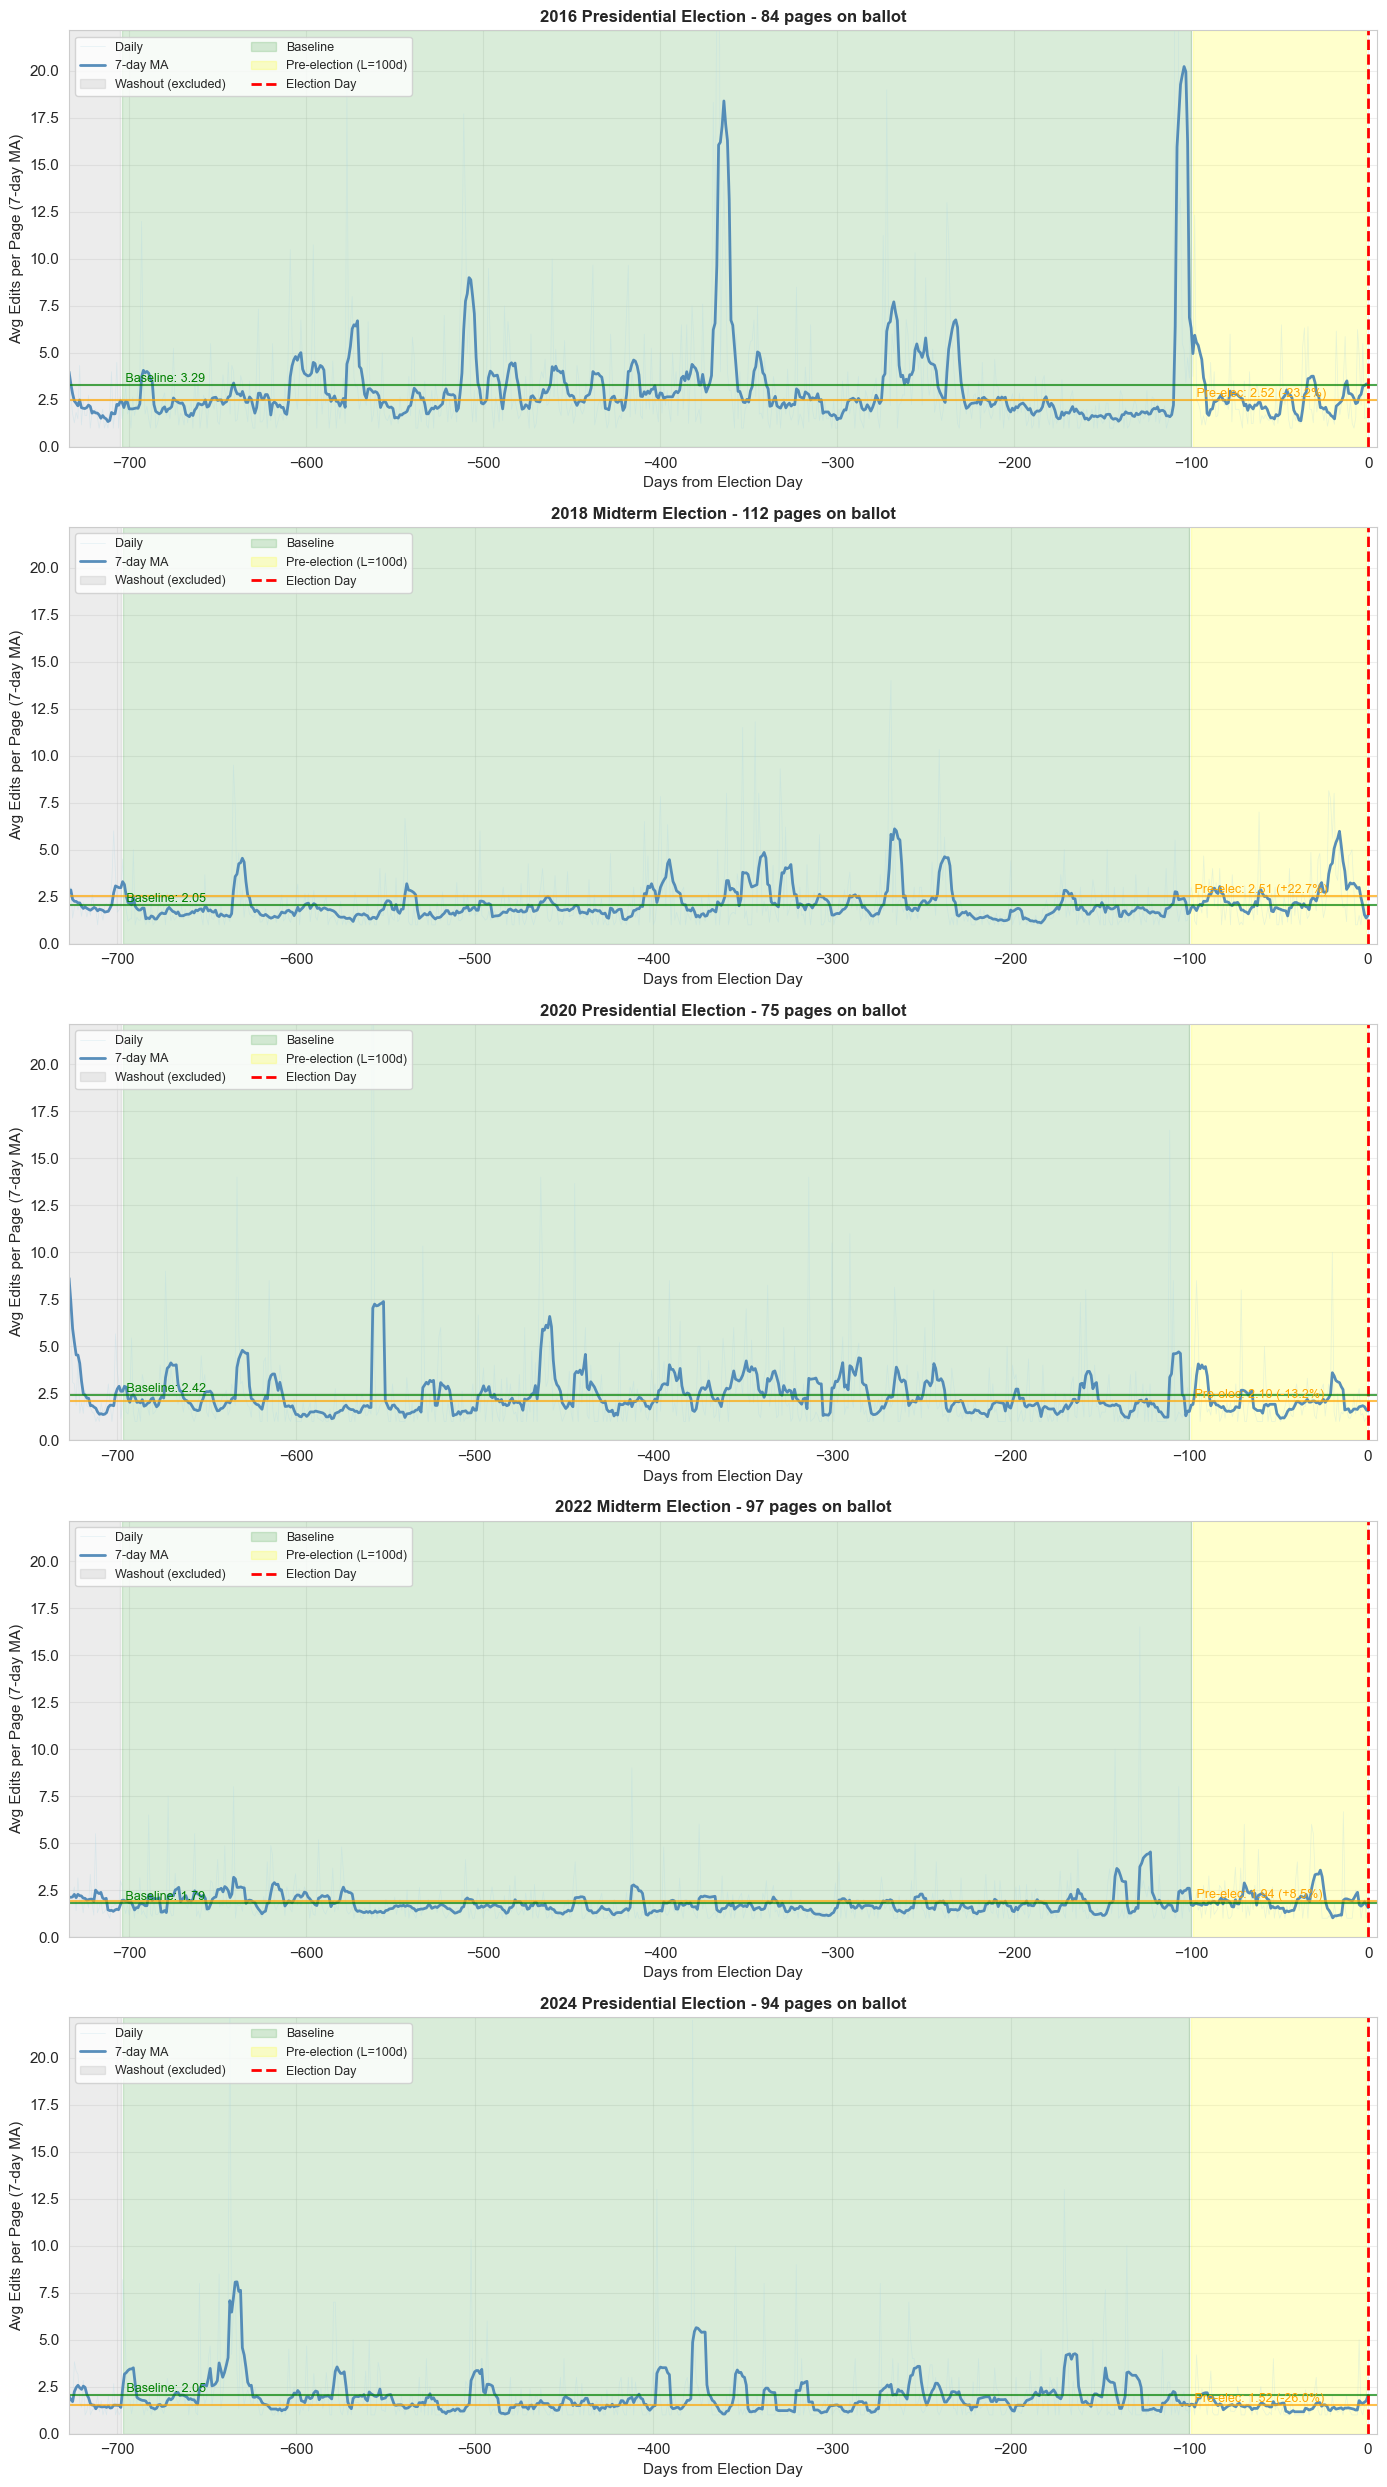


Key:
- Washout (gray): Post-election period excluded from baseline
- Baseline (green): 'Normal' editing period for comparison
- Pre-election (yellow): Event window of interest (L=100 days)
- Horizontal lines show average editing rates for baseline and pre-election windows
- All graphs use the same y-axis scale for easy comparison


In [137]:
# Visualize event study
# For each cycle, show editing pattern with 2-year cycles marked

fig, axes = plt.subplots(len(cycle_results), 1, figsize=(14, 5*len(cycle_results)))
if len(cycle_results) == 1:
    axes = [axes]

# First pass: calculate global y-axis range across all cycles
global_max = 0
global_min = float('inf')

for cycle_info in cycle_results:
    year = cycle_info['year']
    windows = cycle_info['windows']
    
    # Get pages on ballot for this year
    if f'on_ballot_{year}' in df_pages.columns:
        pages_on_ballot = df_pages[df_pages[f'on_ballot_{year}'] == True]['page_title'].tolist()
    else:
        pages_on_ballot = df_pages['page_title'].tolist()
    
    # Filter to cycle dates and on-ballot pages
    df_cycle = df_daily[df_daily['page_title'].isin(pages_on_ballot)].copy()
    cycle_mask = (df_cycle['date'].dt.date >= windows['cycle_start']) & \
                 (df_cycle['date'].dt.date <= windows['cycle_end'])
    df_cycle = df_cycle[cycle_mask]
    
    # Aggregate: average edits per page per day
    daily_cycle = df_cycle.groupby('date')['num_edits'].mean().reset_index()
    
    if len(daily_cycle) > 0:
        daily_cycle.columns = ['date', 'avg_edits_per_page']
        daily_cycle['ma7'] = daily_cycle['avg_edits_per_page'].rolling(window=7, min_periods=1).mean()
        
        global_max = max(global_max, daily_cycle['ma7'].max())
        global_min = min(global_min, daily_cycle['ma7'].min())

# Add some padding to the y-axis range
y_padding = (global_max - global_min) * 0.1
y_min = max(0, global_min - y_padding)  # Don't go below 0
y_max = global_max + y_padding

print(f"Y-axis range across all cycles: [{y_min:.2f}, {y_max:.2f}]\n")

# Second pass: create the plots with consistent y-axis
for i, cycle_info in enumerate(cycle_results):
    year = cycle_info['year']
    windows = cycle_info['windows']
    
    # Get pages on ballot for this year
    if f'on_ballot_{year}' in df_pages.columns:
        pages_on_ballot = df_pages[df_pages[f'on_ballot_{year}'] == True]['page_title'].tolist()
    else:
        pages_on_ballot = df_pages['page_title'].tolist()
    
    # Filter to cycle dates and on-ballot pages
    df_cycle = df_daily[df_daily['page_title'].isin(pages_on_ballot)].copy()
    cycle_mask = (df_cycle['date'].dt.date >= windows['cycle_start']) & \
                 (df_cycle['date'].dt.date <= windows['cycle_end'])
    df_cycle = df_cycle[cycle_mask]
    
    # Aggregate: average edits per page per day
    daily_cycle = df_cycle.groupby('date')['num_edits'].mean().reset_index()
    daily_cycle.columns = ['date', 'avg_edits_per_page']
    
    # Add 7-day moving average
    daily_cycle['ma7'] = daily_cycle['avg_edits_per_page'].rolling(window=7, min_periods=1).mean()
    
    # Convert dates to days from election
    election_day = windows['election_day'][0]
    daily_cycle['days_from_election'] = (daily_cycle['date'].dt.date - election_day).apply(lambda x: x.days)
    
    ax = axes[i]
    
    # Plot the data
    ax.plot(daily_cycle['days_from_election'], daily_cycle['avg_edits_per_page'], 
            linewidth=0.5, alpha=0.3, color='lightblue', label='Daily')
    ax.plot(daily_cycle['days_from_election'], daily_cycle['ma7'], 
            linewidth=2, alpha=0.9, color='steelblue', label='7-day MA')
    
    # Mark windows
    baseline_start_days = (windows['baseline'][0] - election_day).days
    baseline_end_days = (windows['baseline'][1] - election_day).days
    pre_election_start_days = (windows['pre_election'][0] - election_day).days
    pre_election_end_days = (windows['pre_election'][1] - election_day).days
    washout_start_days = (windows['washout'][0] - election_day).days
    washout_end_days = (windows['washout'][1] - election_day).days
    
    # Shade the windows
    ax.axvspan(washout_start_days, washout_end_days, alpha=0.15, color='gray', label='Washout (excluded)')
    ax.axvspan(baseline_start_days, baseline_end_days, alpha=0.15, color='green', label=f'Baseline')
    ax.axvspan(pre_election_start_days, pre_election_end_days, alpha=0.2, color='yellow', label=f'Pre-election (L={PRE_ELECTION_DAYS}d)')
    
    # Mark election day
    ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Election Day')
    
    # Add horizontal line for baseline average
    ax.axhline(cycle_info['baseline_avg'], color='green', linestyle='-', linewidth=1.5, alpha=0.7)
    ax.text(baseline_start_days, cycle_info['baseline_avg'], 
            f" Baseline: {cycle_info['baseline_avg']:.2f}", 
            fontsize=9, color='green', va='bottom')
    
    # Add horizontal line for pre-election average
    ax.axhline(cycle_info['pre_election_avg'], color='orange', linestyle='-', linewidth=1.5, alpha=0.7)
    ax.text(pre_election_start_days, cycle_info['pre_election_avg'], 
            f" Pre-elec: {cycle_info['pre_election_avg']:.2f} ({cycle_info['pct_change']:+.1f}%)", 
            fontsize=9, color='orange', va='bottom')
    
    # Formatting
    ax.set_title(f"{year} {cycle_info['type'].capitalize()} Election - {cycle_info['pages_on_ballot']} pages on ballot", 
                fontsize=12, fontweight='bold')
    ax.set_xlabel('Days from Election Day', fontsize=11)
    ax.set_ylabel('Avg Edits per Page (7-day MA)', fontsize=11)
    ax.legend(loc='upper left', fontsize=9, ncol=2)
    ax.grid(True, alpha=0.3)
    
    # Set x-axis to show the full cycle
    cycle_start_days = (windows['cycle_start'] - election_day).days
    ax.set_xlim(cycle_start_days, 5)  # Show a bit past election day
    
    # Set consistent y-axis across all plots
    ax.set_ylim(y_min, y_max)

plt.tight_layout()
plt.show()

print("\nKey:")
print("- Washout (gray): Post-election period excluded from baseline")
print("- Baseline (green): 'Normal' editing period for comparison")
print(f"- Pre-election (yellow): Event window of interest (L={PRE_ELECTION_DAYS} days)")
print("- Horizontal lines show average editing rates for baseline and pre-election windows")
print("- All graphs use the same y-axis scale for easy comparison")

A spike due to an external event. 

* Date: 2023-10-24
* Days from election: -378
* Total edits: 64
* Pages edited: 1
* Avg edits per page: 64.00

Pages edited on 2023-10-24: - Tom Emmer: 64 edits by 38 editors

Tom Emmer was nominated by House Republicans as Speaker of the House candidate (following Kevin McCarthy's ouster on October 3, 2023). Emmer withdrew his candidacy later the same day due to insufficient support.

## 5. Interpretation and diagnostics
Positive % changes indicate pre-election editing spikes; negative changes indicate lower activity than baseline.

### Abnormal spikes can be due to
- Data collection artifact (e.g., some pages were created/matched late)
- Real editing pattern (e.g., a specific event that triggered edits)
- Sampling issue (e.g., certain high-profile candidates only entered the race later, or wrong page matches)

## 6. Editor Partisan Classification

Classify editors by their editing patterns:
- **Dem-only editors**: Non-bot editors who only edit Democratic candidate pages
- **Rep-only editors**: Non-bot editors who only edit Republican candidate pages  
- **Cross-party editors**: Non-bot editors who edit both Democratic and Republican pages
- **Bot editors**: Accounts in Wikipedia's "bot" user group

Note. An editor who only edits Dem pages in 2016 but edits Rep pages in 2020 would be classified as "Dem-only" in 2016, "Rep-only" in 2020, but "Cross-party" in the 10-year aggregate.


### 6.1 Editor partisan classification

In [138]:
# Load full revision data
df_revisions = pd.read_csv(data_dir / 'all_revisions.csv', parse_dates=['timestamp'])

# Create page-to-party mapping from roster
page_party_map = {}
for page in roster_data['pages']:
    title = page['title']
    party = page.get('primary_party', 'Unknown')
    page_party_map[title] = party

# Add party column to revisions
df_revisions['party'] = df_revisions['page_title'].map(page_party_map)

print(f"Total revisions: {len(df_revisions):,}")
print(f"Unique editors: {df_revisions['user'].nunique():,}")
print(f"\nEdit distribution by party:")
print(df_revisions['party'].value_counts())

# =============================================================================
# FUNCTION: Classify editors for a given subset of data
# =============================================================================

def classify_editors(df_subset):
    """
    Classify editors based on their editing patterns.
    
    Returns:
        Dictionary with counts for each category
    """
    # Separate bots from non-bots
    df_bots = df_subset[df_subset['is_bot'] == True]
    df_non_bots = df_subset[df_subset['is_bot'] == False]
    
    bot_editors = df_bots['user'].unique()
    
    # For non-bots, find which parties each editor has edited
    editor_parties = df_non_bots.groupby('user')['party'].apply(set).to_dict()
    
    dem_only = []
    rep_only = []
    cross_party = []
    other_only = []  # Editors who only edit non-Dem/Rep pages
    
    for editor, parties in editor_parties.items():
        has_dem = 'Democratic' in parties
        has_rep = 'Republican' in parties
        
        if has_dem and has_rep:
            cross_party.append(editor)
        elif has_dem and not has_rep:
            dem_only.append(editor)
        elif has_rep and not has_dem:
            rep_only.append(editor)
        else:
            other_only.append(editor)
    
    return {
        'dem_only': len(dem_only),
        'rep_only': len(rep_only),
        'cross_party': len(cross_party),
        'bot': len(bot_editors),
        'other_only': len(other_only),
        'total_non_bot': len(dem_only) + len(rep_only) + len(cross_party) + len(other_only),
        'total': len(dem_only) + len(rep_only) + len(cross_party) + len(other_only) + len(bot_editors),
        # Also return the actual editor lists for further analysis
        '_dem_only_editors': set(dem_only),
        '_rep_only_editors': set(rep_only),
        '_cross_party_editors': set(cross_party),
        '_bot_editors': set(bot_editors)
    }

# =============================================================================
# ANALYSIS BY CYCLE
# =============================================================================

print("\n" + "="*80)
print("EDITOR CLASSIFICATION BY 2-YEAR CYCLE")
print("="*80)

cycle_results = []

for year in [2016, 2018, 2020, 2022, 2024]:
    # Get cycle windows
    windows = get_cycle_windows(year, PRE_ELECTION_DAYS, WASHOUT_DAYS)
    
    # Filter revisions to this cycle
    cycle_mask = (df_revisions['timestamp'].dt.date >= windows['cycle_start']) & \
                 (df_revisions['timestamp'].dt.date <= windows['cycle_end'])
    df_cycle = df_revisions[cycle_mask]
    
    # Classify editors
    results = classify_editors(df_cycle)
    results['year'] = year
    results['election_type'] = ELECTION_METADATA.get(year, {}).get('type', 'unknown')
    cycle_results.append(results)
    
    print(f"\n{year} {results['election_type'].capitalize()} Cycle ({windows['cycle_start']} to {windows['cycle_end']})")
    print(f"  Total unique editors: {results['total']:,}")
    print(f"  ├── Bot editors: {results['bot']:,} ({100*results['bot']/results['total']:.1f}%)")
    print(f"  └── Non-bot editors: {results['total_non_bot']:,}")
    print(f"      ├── Dem-only: {results['dem_only']:,} ({100*results['dem_only']/results['total_non_bot']:.1f}%)")
    print(f"      ├── Rep-only: {results['rep_only']:,} ({100*results['rep_only']/results['total_non_bot']:.1f}%)")
    print(f"      ├── Cross-party: {results['cross_party']:,} ({100*results['cross_party']/results['total_non_bot']:.1f}%)")
    if results['other_only'] > 0:
        print(f"      └── Other-only: {results['other_only']:,} ({100*results['other_only']/results['total_non_bot']:.1f}%)")

# =============================================================================
# 10-YEAR AGGREGATE (computed fresh, NOT summed)
# =============================================================================

print("\n" + "="*80)
print("10-YEAR AGGREGATE (2015-2024)")
print("="*80)

# Classify over the entire period
results_all = classify_editors(df_revisions)

print(f"\nTotal unique editors across all years: {results_all['total']:,}")
print(f"  ├── Bot editors: {results_all['bot']:,} ({100*results_all['bot']/results_all['total']:.1f}%)")
print(f"  └── Non-bot editors: {results_all['total_non_bot']:,}")
print(f"      ├── Dem-only: {results_all['dem_only']:,} ({100*results_all['dem_only']/results_all['total_non_bot']:.1f}%)")
print(f"      ├── Rep-only: {results_all['rep_only']:,} ({100*results_all['rep_only']/results_all['total_non_bot']:.1f}%)")
print(f"      ├── Cross-party: {results_all['cross_party']:,} ({100*results_all['cross_party']/results_all['total_non_bot']:.1f}%)")
if results_all['other_only'] > 0:
    print(f"      └── Other-only: {results_all['other_only']:,} ({100*results_all['other_only']/results_all['total_non_bot']:.1f}%)")
    

Total revisions: 138,717
Unique editors: 28,652

Edit distribution by party:
party
Republican    76066
Democratic    62651
Name: count, dtype: int64

EDITOR CLASSIFICATION BY 2-YEAR CYCLE

2016 Presidential Cycle (2014-11-05 to 2016-11-08)
  Total unique editors: 6,410
  ├── Bot editors: 31 (0.5%)
  └── Non-bot editors: 6,379
      ├── Dem-only: 2,129 (33.4%)
      ├── Rep-only: 3,675 (57.6%)
      ├── Cross-party: 575 (9.0%)

2018 Midterm Cycle (2016-11-09 to 2018-11-06)
  Total unique editors: 7,322
  ├── Bot editors: 30 (0.4%)
  └── Non-bot editors: 7,292
      ├── Dem-only: 2,526 (34.6%)
      ├── Rep-only: 4,012 (55.0%)
      ├── Cross-party: 754 (10.3%)

2020 Presidential Cycle (2018-11-07 to 2020-11-03)
  Total unique editors: 7,669
  ├── Bot editors: 36 (0.5%)
  └── Non-bot editors: 7,633
      ├── Dem-only: 3,271 (42.9%)
      ├── Rep-only: 3,435 (45.0%)
      ├── Cross-party: 927 (12.1%)

2022 Midterm Cycle (2020-11-04 to 2022-11-08)
  Total unique editors: 6,430
  ├── Bot ed

SUMMARY TABLE: Editor Counts by Category
               Dem-only  Rep-only  Cross-party  Bot  Total
Period                                                    
2016 (pres)        2129      3675          575   31   6410
2018 (midt)        2526      4012          754   30   7322
2020 (pres)        3271      3435          927   36   7669
2022 (midt)        2718      2904          774   34   6430
2024 (pres)        2150      2188          679   32   5049
10-Year Total     11093     14373         3121   65  28652

SUMMARY TABLE: Percentages
(Dem-only, Rep-only, Cross-party as % of non-bot; Bot as % of total)
               Dem-only  Rep-only  Cross-party  Bot
Period                                             
2016 (pres)        33.4      57.6          9.0  0.5
2018 (midt)        34.6      55.0         10.3  0.4
2020 (pres)        42.9      45.0         12.1  0.5
2022 (midt)        42.5      45.4         12.1  0.5
2024 (pres)        42.9      43.6         13.5  0.6
10-Year Total      38.8   

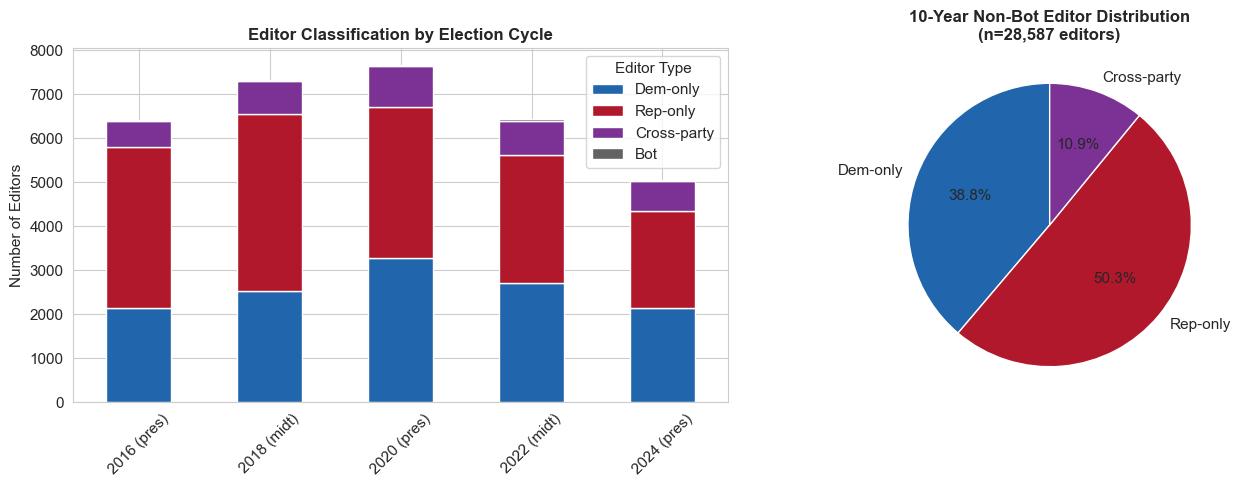

In [139]:
# =============================================================================
# SUMMARY TABLE AND VISUALIZATION
# =============================================================================

# Create summary DataFrame
summary_data = []
for r in cycle_results:
    summary_data.append({
        'Period': f"{r['year']} ({r['election_type'][:4]})",
        'Dem-only': r['dem_only'],
        'Rep-only': r['rep_only'],
        'Cross-party': r['cross_party'],
        'Bot': r['bot'],
        'Total': r['total']
    })

# Add 10-year aggregate
summary_data.append({
    'Period': '10-Year Total',
    'Dem-only': results_all['dem_only'],
    'Rep-only': results_all['rep_only'],
    'Cross-party': results_all['cross_party'],
    'Bot': results_all['bot'],
    'Total': results_all['total']
})

df_summary = pd.DataFrame(summary_data)
df_summary = df_summary.set_index('Period')

print("="*80)
print("SUMMARY TABLE: Editor Counts by Category")
print("="*80)
print(df_summary.to_string())

# Calculate percentages (of non-bot editors)
df_pct = df_summary.copy()
for col in ['Dem-only', 'Rep-only', 'Cross-party']:
    df_pct[col] = (df_summary[col] / (df_summary['Total'] - df_summary['Bot']) * 100).round(1)
df_pct['Bot'] = (df_summary['Bot'] / df_summary['Total'] * 100).round(1)
df_pct = df_pct[['Dem-only', 'Rep-only', 'Cross-party', 'Bot']]

print("\n" + "="*80)
print("SUMMARY TABLE: Percentages")
print("(Dem-only, Rep-only, Cross-party as % of non-bot; Bot as % of total)")
print("="*80)
print(df_pct.to_string())

# =============================================================================
# VISUALIZATION
# =============================================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Stacked bar chart of editor counts by cycle
cycle_df = df_summary.iloc[:-1].copy()  # Exclude 10-year total
cycle_df[['Dem-only', 'Rep-only', 'Cross-party', 'Bot']].plot(
    kind='bar', stacked=True, ax=axes[0],
    color=['#2166ac', '#b2182b', '#7b3294', '#636363']
)
axes[0].set_title('Editor Classification by Election Cycle', fontsize=12, fontweight='bold')
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Editors')
axes[0].legend(title='Editor Type', loc='upper right')
axes[0].tick_params(axis='x', rotation=45)

# Plot 2: Pie chart for 10-year aggregate (non-bot only)
non_bot_data = [results_all['dem_only'], results_all['rep_only'], results_all['cross_party']]
non_bot_labels = ['Dem-only', 'Rep-only', 'Cross-party']
colors = ['#2166ac', '#b2182b', '#7b3294']

axes[1].pie(non_bot_data, labels=non_bot_labels, autopct='%1.1f%%', colors=colors, startangle=90)
axes[1].set_title(f'10-Year Non-Bot Editor Distribution\n(n={results_all["total_non_bot"]:,} editors)', 
                  fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()


### 6.2 Edit counts by editor type

In [140]:
print("\n" + "="*80)
print("EDIT COUNTS BY EDITOR TYPE (10-year aggregate)")
print("="*80)

# Count edits by editor type
dem_only_edits = df_revisions[df_revisions['user'].isin(results_all['_dem_only_editors'])]['user'].count()
rep_only_edits = df_revisions[df_revisions['user'].isin(results_all['_rep_only_editors'])]['user'].count()
cross_party_edits = df_revisions[df_revisions['user'].isin(results_all['_cross_party_editors'])]['user'].count()
bot_edits = df_revisions[df_revisions['is_bot'] == True]['user'].count()

total_edits = len(df_revisions)
other_edits = total_edits - dem_only_edits - rep_only_edits - cross_party_edits - bot_edits

print(f"\nTotal edits: {total_edits:,}")
print(f"  Dem-only editors: {dem_only_edits:,} edits ({100*dem_only_edits/total_edits:.1f}%)")
print(f"  Rep-only editors: {rep_only_edits:,} edits ({100*rep_only_edits/total_edits:.1f}%)")
print(f"  Cross-party editors: {cross_party_edits:,} edits ({100*cross_party_edits/total_edits:.1f}%)")
print(f"  Bot editors: {bot_edits:,} edits ({100*bot_edits/total_edits:.1f}%)")
if other_edits > 0:
    print(f"  Other: {other_edits:,} edits ({100*other_edits/total_edits:.1f}%)")

# Average edits per editor
print(f"\nAverage edits per editor:")
print(f"  Dem-only: {dem_only_edits/results_all['dem_only']:.1f} edits/editor")
print(f"  Rep-only: {rep_only_edits/results_all['rep_only']:.1f} edits/editor")
print(f"  Cross-party: {cross_party_edits/results_all['cross_party']:.1f} edits/editor")
print(f"  Bot: {bot_edits/results_all['bot']:.1f} edits/editor")


EDIT COUNTS BY EDITOR TYPE (10-year aggregate)

Total edits: 138,717
  Dem-only editors: 21,758 edits (15.7%)
  Rep-only editors: 28,589 edits (20.6%)
  Cross-party editors: 79,644 edits (57.4%)
  Bot editors: 8,726 edits (6.3%)

Average edits per editor:
  Dem-only: 2.0 edits/editor
  Rep-only: 2.0 edits/editor
  Cross-party: 25.5 edits/editor
  Bot: 134.2 edits/editor


### 6.3 Smoothed Partisan Lean Measure (smoothing with strong beta shrinkage towards (0,0))

Define a continuous partisan lean score for each editor:

$$s_{e,y} = \frac{D_{e,y} - R_{e,y}}{D_{e,y} + R_{e,y} + 2\alpha}$$

Where:
- $D_{e,y}$ = edits to Democratic pages by editor $e$ in cycle $y$
- $R_{e,y}$ = edits to Republican pages by editor $e$ in cycle $y$  
- $\alpha = 5$ (smoothing parameter that dampens extreme scores from small counts)

**How it works**: The $+2\alpha$ in the denominator acts as Laplace smoothing:
- Small edit counts → score pulled toward 0 (uncertain)
- Large edit counts → α negligible, score approaches raw ratio

**Interpretation**: 
- $s \to +1$: Strong DEM lean (many more DEM edits than REP)
- $s \to -1$: Strong REP lean (many more REP edits than DEM)
- $s \approx 0$: Cross-cutting (balanced) or low activity

**Classification thresholds** (for editors with $D + R \geq 20$):
- DEM-leaning: $s > 0.3$
- REP-leaning: $s < -0.3$
- Cross-cutting: $-0.3 \leq s \leq 0.3$


In [141]:
# =============================================================================
# SMOOTHED PARTISAN LEAN MEASURE
# =============================================================================

ALPHA = 5  # Smoothing parameter
MIN_EDITS_FOR_CLASSIFICATION = 20  # Minimum D+R for classification
DEM_THRESHOLD = 0.3
REP_THRESHOLD = -0.3

def compute_partisan_score(dem_edits, rep_edits, alpha=ALPHA):
    """
    Compute smoothed partisan lean score using Laplace smoothing.
    
    s = (D - R) / (D + R + 2*alpha)
    
    The +2α in denominator acts as regularization:
    - Small edit counts → score dampened toward 0
    - Large edit counts → α negligible, score → (D-R)/(D+R)
    
    Returns:
        Score in range (-1, 1). Always defined for alpha > 0.
    """
    denominator = dem_edits + rep_edits + 2 * alpha
    return (dem_edits - rep_edits) / denominator

def classify_by_score(score, dem_edits, rep_edits, min_edits=MIN_EDITS_FOR_CLASSIFICATION):
    """Classify editor based on score and minimum edit threshold."""
    total = dem_edits + rep_edits
    if total < min_edits:
        return 'Low activity'
    if score > DEM_THRESHOLD:
        return 'DEM-leaning'
    elif score < REP_THRESHOLD:
        return 'REP-leaning'
    else:
        return 'Cross-cutting'

# =============================================================================
# COMPUTE SCORES FOR EACH CYCLE
# =============================================================================

print("="*80)
print("COMPUTING PARTISAN LEAN SCORES BY CYCLE")
print("="*80)
print(f"Parameters: α={ALPHA}, min_edits={MIN_EDITS_FOR_CLASSIFICATION}, thresholds=[{REP_THRESHOLD}, {DEM_THRESHOLD}]")

# Store results for all cycles
all_cycle_scores = {}

for year in [2016, 2018, 2020, 2022, 2024]:
    windows = get_cycle_windows(year, PRE_ELECTION_DAYS, WASHOUT_DAYS)
    
    # Filter to cycle
    cycle_mask = (df_revisions['timestamp'].dt.date >= windows['cycle_start']) & \
                 (df_revisions['timestamp'].dt.date <= windows['cycle_end'])
    df_cycle = df_revisions[cycle_mask & (df_revisions['is_bot'] == False)]
    
    # Count D and R edits per editor
    editor_counts = df_cycle.groupby(['user', 'party']).size().unstack(fill_value=0)
    
    # Ensure both columns exist
    if 'Democratic' not in editor_counts.columns:
        editor_counts['Democratic'] = 0
    if 'Republican' not in editor_counts.columns:
        editor_counts['Republican'] = 0
    
    # Compute scores
    scores_df = pd.DataFrame({
        'user': editor_counts.index,
        'D': editor_counts['Democratic'].values,
        'R': editor_counts['Republican'].values
    })
    scores_df['total'] = scores_df['D'] + scores_df['R']
    scores_df['score'] = scores_df.apply(
        lambda row: compute_partisan_score(row['D'], row['R'], ALPHA), axis=1
    )
    scores_df['classification'] = scores_df.apply(
        lambda row: classify_by_score(row['score'], row['D'], row['R']), axis=1
    )
    scores_df['year'] = year
    
    all_cycle_scores[year] = scores_df
    
    # Summary
    valid_scores = scores_df[scores_df['score'].notna()]
    classified = scores_df[scores_df['total'] >= MIN_EDITS_FOR_CLASSIFICATION]
    
    print(f"\n{year} Cycle:")
    print(f"  Editors with valid scores: {len(valid_scores):,} / {len(scores_df):,}")
    print(f"  Editors meeting threshold (D+R≥{MIN_EDITS_FOR_CLASSIFICATION}): {len(classified):,}")
    if len(classified) > 0:
        class_counts = classified['classification'].value_counts()
        for cls, count in class_counts.items():
            print(f"    {cls}: {count} ({100*count/len(classified):.1f}%)")

# Combine all cycles
df_all_cycle_scores = pd.concat(all_cycle_scores.values(), ignore_index=True)

# =============================================================================
# COMPUTE 10-YEAR AGGREGATE SCORES
# =============================================================================

print("\n" + "="*80)
print("10-YEAR AGGREGATE SCORES")
print("="*80)

# Non-bot revisions only
df_non_bot = df_revisions[df_revisions['is_bot'] == False]

# Count D and R edits per editor across all years
editor_counts_all = df_non_bot.groupby(['user', 'party']).size().unstack(fill_value=0)

if 'Democratic' not in editor_counts_all.columns:
    editor_counts_all['Democratic'] = 0
if 'Republican' not in editor_counts_all.columns:
    editor_counts_all['Republican'] = 0

scores_10yr = pd.DataFrame({
    'user': editor_counts_all.index,
    'D_total': editor_counts_all['Democratic'].values,
    'R_total': editor_counts_all['Republican'].values
})
scores_10yr['total_all'] = scores_10yr['D_total'] + scores_10yr['R_total']
scores_10yr['score_10yr'] = scores_10yr.apply(
    lambda row: compute_partisan_score(row['D_total'], row['R_total'], ALPHA), axis=1
)
scores_10yr['classification_10yr'] = scores_10yr.apply(
    lambda row: classify_by_score(row['score_10yr'], row['D_total'], row['R_total']), axis=1
)

valid_10yr = scores_10yr[scores_10yr['score_10yr'].notna()]
classified_10yr = scores_10yr[scores_10yr['total_all'] >= MIN_EDITS_FOR_CLASSIFICATION]

print(f"Editors with valid 10-year scores: {len(valid_10yr):,} / {len(scores_10yr):,}")
print(f"Editors meeting threshold: {len(classified_10yr):,}")
if len(classified_10yr) > 0:
    class_counts = classified_10yr['classification_10yr'].value_counts()
    for cls, count in class_counts.items():
        print(f"  {cls}: {count} ({100*count/len(classified_10yr):.1f}%)")


COMPUTING PARTISAN LEAN SCORES BY CYCLE
Parameters: α=5, min_edits=20, thresholds=[-0.3, 0.3]

2016 Cycle:
  Editors with valid scores: 6,379 / 6,379
  Editors meeting threshold (D+R≥20): 159
    REP-leaning: 70 (44.0%)
    Cross-cutting: 51 (32.1%)
    DEM-leaning: 38 (23.9%)

2018 Cycle:
  Editors with valid scores: 7,292 / 7,292
  Editors meeting threshold (D+R≥20): 180
    REP-leaning: 83 (46.1%)
    Cross-cutting: 61 (33.9%)
    DEM-leaning: 36 (20.0%)

2020 Cycle:
  Editors with valid scores: 7,633 / 7,633
  Editors meeting threshold (D+R≥20): 223
    Cross-cutting: 93 (41.7%)
    DEM-leaning: 67 (30.0%)
    REP-leaning: 63 (28.3%)

2022 Cycle:
  Editors with valid scores: 6,396 / 6,396
  Editors meeting threshold (D+R≥20): 158
    Cross-cutting: 79 (50.0%)
    REP-leaning: 53 (33.5%)
    DEM-leaning: 26 (16.5%)

2024 Cycle:
  Editors with valid scores: 5,017 / 5,017
  Editors meeting threshold (D+R≥20): 127
    Cross-cutting: 75 (59.1%)
    REP-leaning: 28 (22.0%)
    DEM-leanin

Using consistent y-axis scale for 5 cycle graphs: [0, 3098]


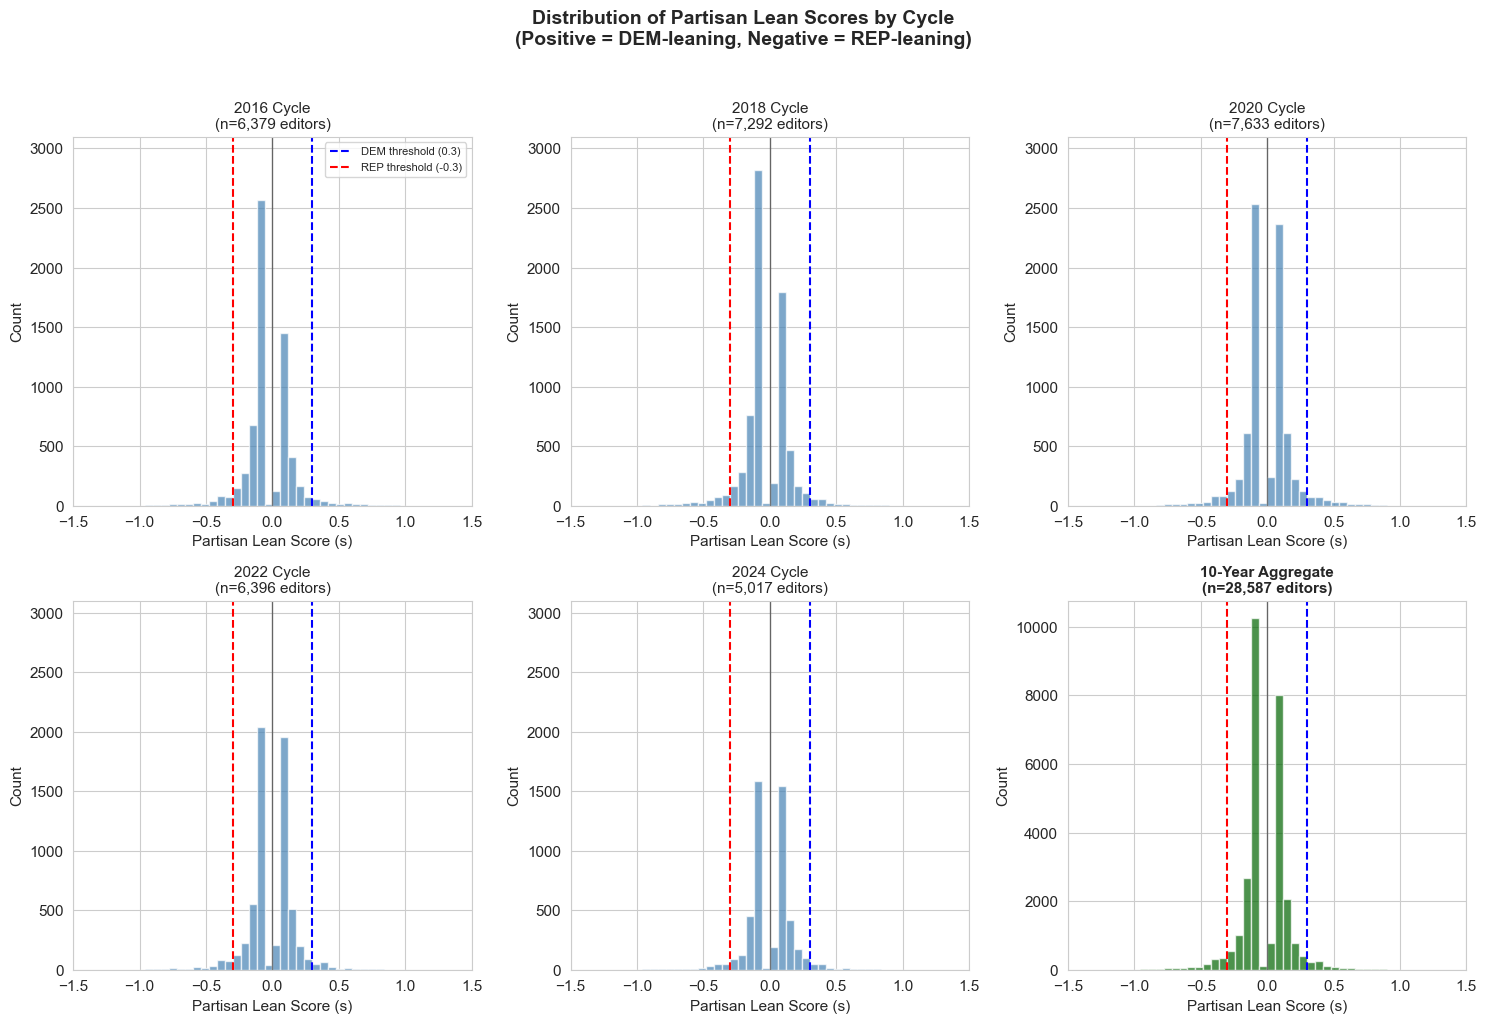


Note: The 5 cycle graphs use the same y-axis scale for easy comparison.
The 10-year aggregate (bottom right) uses its own scale due to different sample size.


In [142]:
# =============================================================================
# VISUALIZATION: DISTRIBUTION OF PARTISAN LEAN SCORES
# =============================================================================

fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

# Compute histograms to find max y-value across all 5 cycles
max_count_cycles = 0
for year in [2016, 2018, 2020, 2022, 2024]:
    scores_df = all_cycle_scores[year]
    valid = scores_df[scores_df['score'].notna()]['score']
    counts, _ = np.histogram(valid, bins=50, range=(-1.5, 1.5))
    max_count_cycles = max(max_count_cycles, counts.max())

# Add 10% padding
y_max_cycles = max_count_cycles * 1.1

print(f"Using consistent y-axis scale for 5 cycle graphs: [0, {y_max_cycles:.0f}]")

# Plot with consistent y-axis
for i, year in enumerate([2016, 2018, 2020, 2022, 2024]):
    ax = axes[i]
    scores_df = all_cycle_scores[year]
    valid = scores_df[scores_df['score'].notna()]['score']
    
    ax.hist(valid, bins=50, range=(-1.5, 1.5), color='steelblue', edgecolor='white', alpha=0.7)
    ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
    ax.axvline(DEM_THRESHOLD, color='blue', linestyle='--', linewidth=1.5, label=f'DEM threshold ({DEM_THRESHOLD})')
    ax.axvline(REP_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'REP threshold ({REP_THRESHOLD})')
    ax.set_title(f'{year} Cycle\n(n={len(valid):,} editors)', fontsize=11)
    ax.set_xlabel('Partisan Lean Score (s)')
    ax.set_ylabel('Count')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(0, y_max_cycles)  # Consistent y-axis across all 5 cycles
    if i == 0:
        ax.legend(fontsize=8)

# Plot 10-year aggregate distribution (separate scale - different sample size)
ax = axes[5]
valid_10yr_scores = scores_10yr[scores_10yr['score_10yr'].notna()]['score_10yr']
ax.hist(valid_10yr_scores, bins=50, range=(-1.5, 1.5), color='darkgreen', edgecolor='white', alpha=0.7)
ax.axvline(0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax.axvline(DEM_THRESHOLD, color='blue', linestyle='--', linewidth=1.5)
ax.axvline(REP_THRESHOLD, color='red', linestyle='--', linewidth=1.5)
ax.set_title(f'10-Year Aggregate\n(n={len(valid_10yr_scores):,} editors)', fontsize=11, fontweight='bold')
ax.set_xlabel('Partisan Lean Score (s)')
ax.set_ylabel('Count')
ax.set_xlim(-1.5, 1.5)
# Note: 10-year aggregate uses its own scale (different sample size)

plt.suptitle('Distribution of Partisan Lean Scores by Cycle\n(Positive = DEM-leaning, Negative = REP-leaning)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\nNote: The 5 cycle graphs use the same y-axis scale for easy comparison.")
print("The 10-year aggregate (bottom right) uses its own scale due to different sample size.")


### 6.4 Stability analysis for editor partisan leaning

The 10-year score $s_e$ serves as a "baseline" or "true" partisan lean. I compare each cycle's score $s_{e,y}$ to this baseline to assess stability.

* High correlation = editors are consistent in their partisan lean over time
* Points far from diagonal = editors whose cycle behavior differs from overall pattern

STABILITY ANALYSIS: Comparing Cycle Scores to 10-Year Aggregate


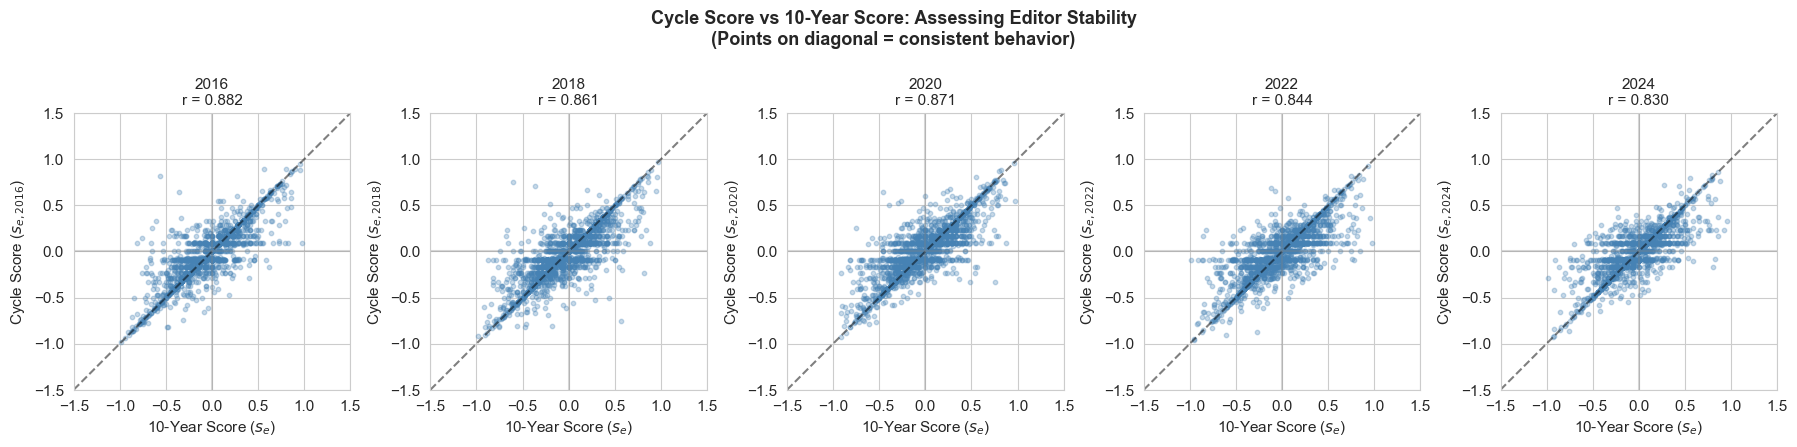


Correlation between cycle scores and 10-year scores:
  2016: r = 0.882 (High stability)
  2018: r = 0.861 (High stability)
  2020: r = 0.871 (High stability)
  2022: r = 0.844 (High stability)
  2024: r = 0.830 (High stability)

Interpretation:
  - Points above diagonal: Editor more DEM-leaning in that cycle than overall
  - Points below diagonal: Editor more REP-leaning in that cycle than overall

  - Strong correlation suggests that editors maintain consistent partisan lean across cycles


In [143]:
print("="*80)
print("STABILITY ANALYSIS: Comparing Cycle Scores to 10-Year Aggregate")
print("="*80)

# Merge cycle scores with 10-year scores
stability_data = []

for year in [2016, 2018, 2020, 2022, 2024]:
    cycle_df = all_cycle_scores[year][['user', 'score', 'total']].copy()
    cycle_df.columns = ['user', f'score_{year}', f'total_{year}']
    
    merged = cycle_df.merge(
        scores_10yr[['user', 'score_10yr', 'total_all']], 
        on='user', 
        how='inner'
    )
    merged['year'] = year
    stability_data.append(merged)

df_stability = pd.concat(stability_data, ignore_index=True)

# For visualization, we need editors who appear in multiple cycles
# and have valid scores in both cycle and 10-year aggregate
fig, axes = plt.subplots(1, 5, figsize=(18, 4))

correlations = {}

for i, year in enumerate([2016, 2018, 2020, 2022, 2024]):
    ax = axes[i]
    
    # Get data for this cycle
    cycle_df = all_cycle_scores[year].copy()
    merged = cycle_df.merge(scores_10yr[['user', 'score_10yr']], on='user', how='inner')
    
    # Filter to valid scores only
    valid = merged[(merged['score'].notna()) & (merged['score_10yr'].notna())]
    
    if len(valid) > 10:
        # Scatter plot
        ax.scatter(valid['score_10yr'], valid['score'], alpha=0.3, s=10, c='steelblue')
        
        # Add diagonal line (perfect stability)
        ax.plot([-1.5, 1.5], [-1.5, 1.5], 'k--', alpha=0.5, label='Perfect stability')
        
        # Compute correlation
        corr = valid['score'].corr(valid['score_10yr'])
        correlations[year] = corr
        
        ax.set_title(f'{year}\nr = {corr:.3f}', fontsize=11)
    else:
        ax.set_title(f'{year}\n(insufficient data)', fontsize=11)
    
    ax.set_xlabel('10-Year Score ($s_e$)')
    ax.set_ylabel(f'Cycle Score ($s_{{e,{year}}}$)')
    ax.set_xlim(-1.5, 1.5)
    ax.set_ylim(-1.5, 1.5)
    ax.axhline(0, color='gray', linestyle='-', alpha=0.3)
    ax.axvline(0, color='gray', linestyle='-', alpha=0.3)
    ax.set_aspect('equal')

plt.suptitle('Cycle Score vs 10-Year Score: Assessing Editor Stability\n(Points on diagonal = consistent behavior)', 
             fontsize=13, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("\nCorrelation between cycle scores and 10-year scores:")
for year, corr in correlations.items():
    stability_level = "High" if corr > 0.7 else "Moderate" if corr > 0.4 else "Low"
    print(f"  {year}: r = {corr:.3f} ({stability_level} stability)")

print("\nInterpretation:")
print("  - Points above diagonal: Editor more DEM-leaning in that cycle than overall")
print("  - Points below diagonal: Editor more REP-leaning in that cycle than overall")
print("\n  - Strong correlation suggests that editors maintain consistent partisan lean across cycles")

